In [ ]:
from pyspark.sql import SparkSession
from pathlib import Path
from pyspark.sql import functions as F
import matplotlib.pyplot as plt
from pyspark.sql.window import Window


file_path = Path.cwd()
data_path = file_path.parent / "output" / "cleaned.parquet"

spark = (
    SparkSession.builder.appName("clickstream-exploration")
    .master("local[*]")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("ERROR")
df = spark.read.parquet(str(data_path))
df.printSchema()

root
 |-- order: integer (nullable = true)
 |-- country: integer (nullable = true)
 |-- session_id: integer (nullable = true)
 |-- page_1_main_category: string (nullable = true)
 |-- page_2_clothing_model: string (nullable = true)
 |-- colour: string (nullable = true)
 |-- location: string (nullable = true)
 |-- model_photography: string (nullable = true)
 |-- price: integer (nullable = true)
 |-- price_2: boolean (nullable = true)
 |-- page: integer (nullable = true)
 |-- date: date (nullable = true)



In [46]:
# constants
eu_codes = [
    2,
    3,
    8,
    9,
    10,
    11,
    14,
    15,
    16,
    17,
    18,
    21,
    22,
    23,
    24,
    25,
    27,
    30,
    34,
    35,
    36,
    37,
    41,
]
non_eu_europe_codes = [7, 19, 28, 31, 32, 33, 38, 39]
outside_europe_codes = [1, 4, 5, 6, 20, 26, 40, 42]
unidentified_codes = [12, 43, 44, 45, 46, 47]

colour_map = {
    1: "beige",
    2: "black",
    3: "blue",
    4: "brown",
    5: "burgundy",
    6: "gray",
    7: "green",
    8: "navy blue",
    9: "many colors",
    10: "olive",
    11: "pink",
    12: "red",
    13: "violet",
    14: "white",
}

import matplotlib.pyplot as plt


def plot_df(
    df,
    x=None,
    y=None,
    kind="line",
    figsize=(8, 5),
    xlabel=None,
    ylabel=None,
    title=None,
    rotation=0,
    grid=False,
    legend=True,
    **kwargs
):
    """
    Reusable plotting function for pandas DataFrames.

    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame to plot from.
    x : str, optional
        Column for x-axis.
    y : str or list[str], optional
        Column(s) for y-axis.
    kind : str, default="line"
        Plot type: 'line', 'bar', 'barh', 'hist', 'box', 'kde', 'area', 'scatter', etc.
    figsize : tuple, default=(8, 5)
        Figure size.
    xlabel, ylabel, title : str, optional
        Labels and title.
    rotation : int, default=0
        Rotation for x tick labels.
    grid : bool, default=False
        Whether to show grid.
    legend : bool, default=True
        Whether to show legend.
    **kwargs
        Extra arguments passed to df.plot().
    """
    ax = df.plot(
        x=x, y=y, kind=kind, figsize=figsize, legend=legend, grid=grid, **kwargs
    )

    if xlabel is not None:
        ax.set_xlabel(xlabel)
    elif x is not None:
        ax.set_xlabel(x)

    if ylabel is not None:
        ax.set_ylabel(ylabel)
    elif y is not None and isinstance(y, str):
        ax.set_ylabel(y)

    if title is not None:
        ax.set_title(title)

    plt.xticks(rotation=rotation)
    plt.tight_layout()
    plt.show()

In [47]:
# add region column based on country codes
df = df.withColumn(
    "region",
    F.when(F.col("country") == 29, "Poland")
    .when(F.col("country").isin(eu_codes), "Other_EU")
    .when(F.col("country").isin(non_eu_europe_codes), "Europe_non_EU")
    .when(F.col("country").isin(outside_europe_codes), "Outside_Europe")
    .otherwise("Unidentified_or_Domain"),
)

In [48]:
# session-level features
session_df = df.groupBy("session_id", "region").agg(
    F.count("*").alias("num_clicks"),
    F.countDistinct("page_2_clothing_model").alias("num_unique_products"),
    F.countDistinct("page_1_main_category").alias("num_unique_categories"),
    F.avg("price").alias("avg_price_viewed"),
    F.max("page").alias("max_page"),
    F.max("order").alias("max_order(clicks)"),
    F.avg(F.col("price_2").cast("int")).alias("share_above_avg_price"),
)
session_df.show(5)

+----------+--------+----------+-------------------+---------------------+------------------+--------+-----------------+---------------------+
|session_id|  region|num_clicks|num_unique_products|num_unique_categories|  avg_price_viewed|max_page|max_order(clicks)|share_above_avg_price|
+----------+--------+----------+-------------------+---------------------+------------------+--------+-----------------+---------------------+
|      6883|  Poland|        27|                 23|                    4| 44.18518518518518|       4|               27|   0.7777777777777778|
|     11760|Other_EU|         9|                  9|                    2|40.888888888888886|       5|                9|   0.5555555555555556|
|     15001|  Poland|        20|                 17|                    2|              38.0|       5|               20|                  0.7|
|      8651|  Poland|         7|                  7|                    3| 38.42857142857143|       3|                7|   0.2857142857142857|

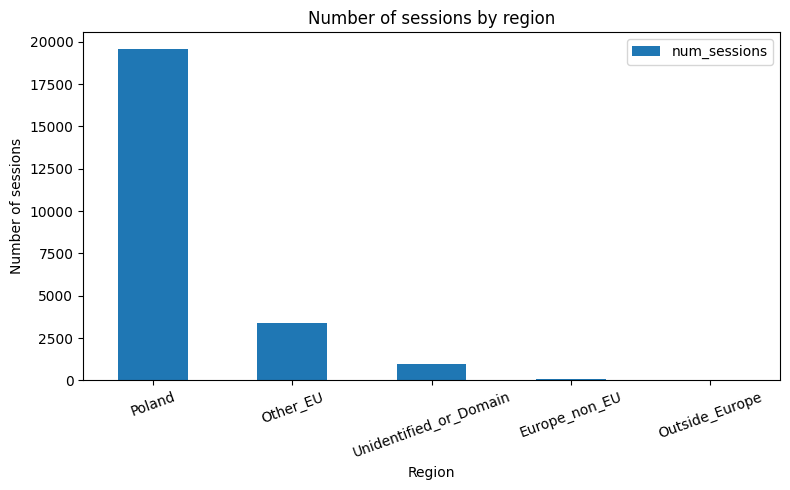

+----------------------+------------+----------------------+-------------------+-----------------+-------------------------+-------------------+
|region                |num_sessions|avg_clicks_per_session|avg_unique_products|avg_session_price|avg_share_above_avg_price|share_page1_only   |
+----------------------+------------+----------------------+-------------------+-----------------+-------------------------+-------------------+
|Poland                |19582       |6.84112960882443      |6.199979573077316  |44.14280141758586|0.5203717084487669       |0.38458788683484835|
|Other_EU              |3372        |7.890865954922894     |6.683867141162515  |45.49126236279448|0.4946325356950653       |0.40065243179122184|
|Unidentified_or_Domain|959         |4.340980187695516     |3.9249217935349323 |45.21283732620672|0.5151756892393697       |0.6277372262773723 |
|Europe_non_EU         |79          |6.886075949367089     |5.974683544303797  |44.52395569728034|0.5464456199936469       |0.3670

In [49]:
# sessions by region
sessions_by_region = (
    session_df.groupBy("region")
    .agg(
        F.count("*").alias("num_sessions"),
        F.avg("num_clicks").alias("avg_clicks_per_session"),
        F.avg("num_unique_products").alias("avg_unique_products"),
        F.avg("avg_price_viewed").alias("avg_session_price"),
        F.avg("share_above_avg_price").alias("avg_share_above_avg_price"),
        F.avg(F.when(F.col("max_page") == 1, 1).otherwise(0)).alias("share_page1_only"),
    )
    .orderBy(F.desc("num_sessions"))
)

pdf = sessions_by_region.toPandas()

plot_df(
    pdf,
    x="region",
    y="num_sessions",
    kind="bar",
    xlabel="Region",
    ylabel="Number of sessions",
    title="Number of sessions by region",
    rotation=20,
)

sessions_by_region.show(truncate=False)

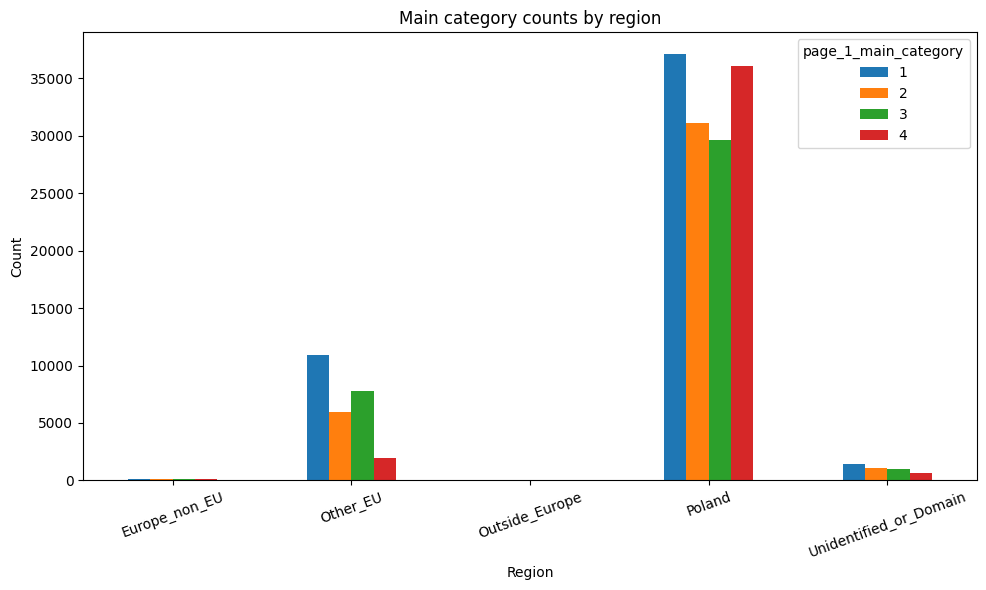

+-------------+--------------------+-----+
|region       |page_1_main_category|count|
+-------------+--------------------+-----+
|Europe_non_EU|2                   |161  |
|Europe_non_EU|1                   |153  |
|Europe_non_EU|3                   |141  |
|Europe_non_EU|4                   |89   |
|Other_EU     |1                   |10943|
+-------------+--------------------+-----+
only showing top 5 rows



In [50]:
# top categories by region
top_categories = (
    df.groupBy("region", "page_1_main_category")
    .count()
    .orderBy("region", F.desc("count"))
)

pdf = top_categories.toPandas()
pivot = pdf.pivot(
    index="region", columns="page_1_main_category", values="count"
).fillna(0)

plot_df(
    pivot,
    kind="bar",
    figsize=(10, 6),
    xlabel="Region",
    ylabel="Count",
    title="Main category counts by region",
    rotation=20,
)

top_categories.show(5, truncate=False)

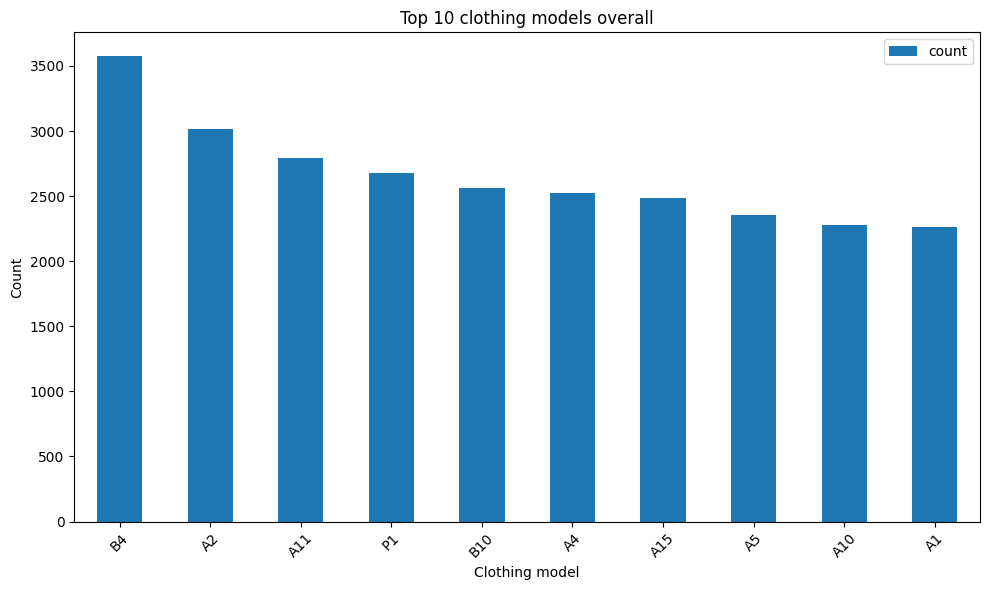

In [51]:
# top products by region
top_products = (
    df.groupBy("region", "page_2_clothing_model")
    .count()
    .orderBy("region", F.desc("count"))
)

top_products_overall = (
    df.groupBy("page_2_clothing_model").count().orderBy(F.desc("count")).limit(10)
)

pdf = top_products_overall.toPandas()

plot_df(
    pdf,
    x="page_2_clothing_model",
    y="count",
    kind="bar",
    figsize=(10, 6),
    xlabel="Clothing model",
    ylabel="Count",
    title="Top 10 clothing models overall",
    rotation=45,
)

In [ ]:
# top-5 colours per region
top_colours = df.groupBy("region", "colour").count()

w = Window.partitionBy("region").orderBy(F.desc("count"))

top5_colours = (
    top_colours.withColumn("rank", F.row_number().over(w))
    .filter(F.col("rank") <= 5)
    .orderBy("region", "rank")
)

pdf = top5_colours.toPandas()
pdf.head(5)

,region,colour,count,rank
0,Europe_non_EU,2,129,1
1,Europe_non_EU,3,72,2
2,Europe_non_EU,6,60,3
3,Europe_non_EU,14,51,4
4,Europe_non_EU,9,48,5


+--------------------+---------------------+------------------+
|              region|share_above_avg_price|         avg_price|
+--------------------+---------------------+------------------+
|       Europe_non_EU|   0.5496323529411765|45.064338235294116|
|      Outside_Europe|   0.5255102040816326| 45.10204081632653|
|Unidentified_or_D...|    0.515013211626231|44.835455200576504|
|              Poland|   0.5148660451020057|43.470592626322194|
|            Other_EU|   0.4951894167167769|45.276608538785325|
+--------------------+---------------------+------------------+



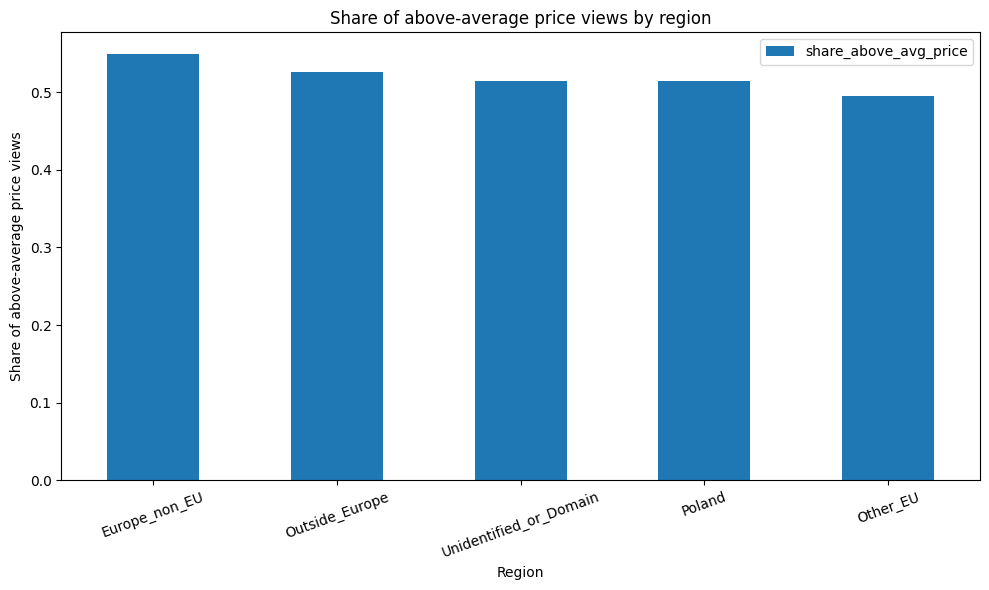

In [68]:
# above-average price preference by region
price_pref = (
    df.groupBy("region")
    .agg(
        F.avg(F.col("price_2").cast("int")).alias("share_above_avg_price"),
        F.avg("price").alias("avg_price"),
    )
    .orderBy(F.desc("share_above_avg_price"))
)
price_pref.show()

pdf = price_pref.toPandas()
plot_df(
    pdf,
    x="region",
    y="share_above_avg_price",
    kind="bar",
    figsize=(10, 6),
    xlabel="Region",
    ylabel=("Share of above-average price views"),
    title="Share of above-average price views by region",
    rotation=20,
)

In [69]:
# page-depth analysis
page_depth = session_df.groupBy("region").agg(
    F.avg("max_page").alias("avg_max_page"),
    F.avg(F.when(F.col("max_page") == 1, 1).otherwise(0)).alias("share_only_page1"),
)
page_depth.show()

+--------------------+------------------+-------------------+
|              region|      avg_max_page|   share_only_page1|
+--------------------+------------------+-------------------+
|       Europe_non_EU|2.3544303797468356| 0.3670886075949367|
|            Other_EU|2.1755634638196915|0.40065243179122184|
|      Outside_Europe|2.2058823529411766| 0.2647058823529412|
|Unidentified_or_D...|1.7288842544316998| 0.6277372262773723|
|              Poland| 2.288326013686038|0.38458788683484835|
+--------------------+------------------+-------------------+



In [70]:
# product views per session
basket_df = df.select("session_id", "region", "page_2_clothing_model").dropDuplicates(
    ["session_id", "page_2_clothing_model"]
)
basket_df.show(5)

+----------+------+---------------------+
|session_id|region|page_2_clothing_model|
+----------+------+---------------------+
|         1|Poland|                  A13|
|         1|Poland|                  A16|
|         1|Poland|                  B17|
|         1|Poland|                   B4|
|         1|Poland|                   B8|
+----------+------+---------------------+
only showing top 5 rows



In [76]:
# product pairs in same session
a = basket_df.alias("a")
b = basket_df.alias("b")

pairs = a.join(
    b,
    on=[
        F.col("a.session_id") == F.col("b.session_id"),
        F.col("a.page_2_clothing_model") < F.col("b.page_2_clothing_model"),
    ],
    how="inner",
).select(
    F.col("a.region").alias(
        "region"
    ),  # note: I already checked there is no sessions in which country(region) changes
    F.col("a.page_2_clothing_model").alias("item_A"),
    F.col("b.page_2_clothing_model").alias("item_B"),
    F.col("a.session_id").alias("session_id"),
) # note: checked for duplications, there are none
pairs.show(5)

+------+------+------+----------+
|region|item_A|item_B|session_id|
+------+------+------+----------+
|Poland|   A13|   B17|         1|
|Poland|   A13|    B4|         1|
|Poland|   A13|   P82|         1|
|Poland|   A13|   P67|         1|
|Poland|   A13|   C56|         1|
+------+------+------+----------+
only showing top 5 rows



In [ ]:
# support
pair_counts = (
    pairs.groupBy("region", "item_A", "item_B")
    .count()
    .withColumnRenamed("count", "pair_count")
)
session_counts = basket_df.groupBy("region").agg(
    F.countDistinct("session_id").alias("num_sessions")
)
item_counts = (
    basket_df.groupBy("region", "page_2_clothing_model")
    .agg(F.countDistinct("session_id").alias("item_sessions"))
    .withColumnRenamed("page_2_clothing_model", "item")
)

print("pair_counts:")
pair_counts.show(5)

print("session_counts:")
session_counts.show(5)

print("item_counts:")
item_counts.show(5)

pair_counts:
+--------+------+------+----------+
|  region|item_A|item_B|pair_count|
+--------+------+------+----------+
|Other_EU|   C34|   C49|        32|
|Other_EU|   B13|   B23|        40|
|Other_EU|   B26|   C47|         9|
|  Poland|   A35|   C53|        23|
|  Poland|    A2|    P2|       246|
+--------+------+------+----------+
only showing top 5 rows

session_counts:
+--------------------+------------+
|              region|num_sessions|
+--------------------+------------+
|       Europe_non_EU|          79|
|            Other_EU|        3372|
|      Outside_Europe|          34|
|Unidentified_or_D...|         959|
|              Poland|       19582|
+--------------------+------------+

item_counts:
+--------------------+----+-------------+
|              region|item|item_sessions|
+--------------------+----+-------------+
|            Other_EU|  P5|           22|
|Unidentified_or_D...| A38|            8|
|Unidentified_or_D...| P30|            5|
|            Other_EU| B20|     

In [58]:
# confidence and lift
rules = (
    pair_counts.join(session_counts, on="region")
    .join(
        item_counts.withColumnRenamed("item", "item_A").withColumnRenamed(
            "item_sessions", "item_A_sessions"
        ),
        on=["region", "item_A"],
    )
    .join(
        item_counts.withColumnRenamed("item", "item_B").withColumnRenamed(
            "item_sessions", "item_B_sessions"
        ),
        on=["region", "item_B"],
    )
    .withColumn("support", F.col("pair_count") / F.col("num_sessions"))
    .withColumn("confidence_A_to_B", F.col("pair_count") / F.col("item_A_sessions"))
    .withColumn("confidence_B_to_A", F.col("pair_count") / F.col("item_B_sessions"))
    .withColumn(
        "lift_A_to_B",
        (F.col("pair_count") / F.col("item_A_sessions"))
        / (F.col("item_B_sessions") / F.col("num_sessions")),
    )
    .orderBy(F.desc("support"))
)

rules.show(20, truncate=False)

+--------------+------+------+----------+------------+---------------+---------------+--------------------+-------------------+-------------------+------------------+
|region        |item_B|item_A|pair_count|num_sessions|item_A_sessions|item_B_sessions|support             |confidence_A_to_B  |confidence_B_to_A  |lift_A_to_B       |
+--------------+------+------+----------+------------+---------------+---------------+--------------------+-------------------+-------------------+------------------+
|Outside_Europe|A33   |A21   |4         |34          |7              |5              |0.11764705882352941 |0.5714285714285714 |0.8                |3.8857142857142852|
|Outside_Europe|C8    |A33   |4         |34          |5              |4              |0.11764705882352941 |0.8                |1.0                |6.800000000000001 |
|Outside_Europe|C35   |A33   |3         |34          |5              |3              |0.08823529411764706 |0.6                |1.0                |6.799999999999999 